# Occupational-Hazard Exposure Phenotyping of Korean Workers

Unsupervised machine-learning typology of **18 occupational hazard exposures** (physical, ergonomic, psychosocial) from the **7th Korean Working Conditions Survey (KWCS, 2023)**.  
*Paper 1 — KSCI 2026.* Runs on **Google Colab** (mounts Drive) or locally; prints every result (text, tables, figures) to screen and saves a timestamped copy to `output/run_<timestamp>/`.

In [1]:
# === Cell 1 · Setup & environment ============================================
import os
for _v in ("OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS","NUMEXPR_NUM_THREADS"):
    os.environ[_v]="1"                      # deterministic BLAS threads
os.environ["PYTHONHASHSEED"]="0"
import numpy as np, pandas as pd, random, warnings, datetime as dt
warnings.filterwarnings("ignore"); random.seed(0); np.random.seed(0)
import matplotlib, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)
from scipy import stats
try:
    from IPython.display import display
except Exception:
    display=print

# ---- locate the project folder (Google Colab Drive or local) ----
CAND=[]
try:
    from google.colab import drive; drive.mount("/content/drive")
    CAND.append("/content/drive/MyDrive/완석_구글자료/연구자료/20260313_kosha/4. 제주학술대회/컴퓨터정보_논문1")
except Exception:
    pass
CAND += ["<PROJECT_ROOT> 드라이브/완석_구글자료/연구자료/20260313_kosha/4. 제주학술대회/컴퓨터정보_논문1",
         os.getcwd()]
BASE=next((p for p in CAND if os.path.exists(os.path.join(p,"input"))), CAND[-1])
INP=os.path.join(BASE,"input","(데이터) 2023년 제7차 근로환경조사.csv")
TS=dt.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT=os.path.join(BASE,"output","run_"+TS); os.makedirs(OUT,exist_ok=True)
print("BASE:",BASE); print("DATA found:",os.path.exists(INP)); print("OUTPUT:",OUT)

# ---- publication figure style (English only) ----
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":9,"axes.linewidth":0.8,"axes.titlesize":10,
 "axes.labelsize":9,"xtick.labelsize":8,"ytick.labelsize":8,"legend.fontsize":8,"figure.dpi":110,
 "savefig.dpi":300,"savefig.bbox":"tight","axes.spines.top":False,"axes.spines.right":False})
PALETTE=["#0072B2","#E69F00","#009E73","#D55E00"]   # Okabe-Ito (CVD-safe)
def save(fig,name): fig.savefig(os.path.join(OUT,name+".png")); fig.savefig(os.path.join(OUT,name+".pdf"))

BASE: <PROJECT_ROOT> 드라이브/완석_구글자료/연구자료/20260313_kosha/4. 제주학술대회/컴퓨터정보_논문1
DATA found: True
OUTPUT: <PROJECT_ROOT> 드라이브/완석_구글자료/연구자료/20260313_kosha/4. 제주학술대회/컴퓨터정보_논문1/output/run_20260607_190631


In [2]:
# === Cell 2 · Load data, define analytic sample, recode 18 hazard exposures ===
PHY=[f"hazard_phy{i}" for i in range(1,10)]; ERG=[f"hazard_erg{i}" for i in range(1,7)]; PSY=[f"hazard_psy{i}" for i in range(1,4)]
HAZ=PHY+ERG+PSY
LBL={"hazard_phy1":"Vibration","hazard_phy2":"Loud noise","hazard_phy3":"High temperature","hazard_phy4":"Low temperature",
 "hazard_phy5":"Fumes / dust","hazard_phy6":"Solvent vapours","hazard_phy7":"Chemicals (skin)","hazard_phy8":"Secondhand smoke",
 "hazard_phy9":"Infectious material","hazard_erg1":"Painful postures","hazard_erg2":"Lifting people","hazard_erg3":"Heavy loads",
 "hazard_erg4":"Prolonged standing","hazard_erg5":"Prolonged sitting","hazard_erg6":"Repetitive movements",
 "hazard_psy1":"Handling customers","hazard_psy2":"Angry clients","hazard_psy3":"Emotionally disturbing"}
need=HAZ+["age","gender","occ","emp_type","wshift","wt2","wt3","heal_wsick1","heal_abs1","wbalance","weng1","weng2","weng3"]
df=pd.read_csv(INP,encoding="utf-8-sig",usecols=lambda c:c.strip() in need,low_memory=False)
df.columns=[c.strip() for c in df.columns]
n0=len(df); df=df[(df.age>=15)&(df.age<=69)].copy(); n1=len(df)
# original scale 1=all the time ... 7=never (8/9 = don't know/refuse). Reverse so HIGHER = MORE exposure.
for c in HAZ:
    df[c]=df[c].where(df[c].between(1,7)); df[c]=8-df[c]
df=df[df[HAZ].notna().all(axis=1)].copy(); n2=len(df)
print(f"Analytic sample:  total {n0:,}  ->  working age 15-69 {n1:,}  ->  complete 18-hazard data {n2:,}")
Xz=StandardScaler().fit_transform(df[HAZ].values.astype(float))
display(pd.DataFrame({"domain":["Physical"]*9+["Ergonomic"]*6+["Psychosocial"]*3,
    "label":[LBL[h] for h in HAZ],"mean exposure (0-6)":df[HAZ].mean().round(2).values},index=HAZ))

Analytic sample:  total 50,195  ->  working age 15-69 44,535  ->  complete 18-hazard data 44,125


,domain,label,mean exposure (0-6)
hazard_phy1,Physical,Vibration,1.89
hazard_phy2,Physical,Loud noise,1.69
hazard_phy3,Physical,High temperature,1.82
hazard_phy4,Physical,Low temperature,1.65
hazard_phy5,Physical,Fumes / dust,1.55
hazard_phy6,Physical,Solvent vapours,1.40
hazard_phy7,Physical,Chemicals (skin),1.43
hazard_phy8,Physical,Secondhand smoke,1.42
hazard_phy9,Physical,Infectious material,1.35
hazard_erg1,Ergonomic,Painful postures,2.57


In [ ]:
# === Cell 2b · Figure 1: participant selection flow diagram =================
# pad-aware geometry: FancyBboxPatch pad(P)만큼 박스가 부풀므로 실제 테두리 기준으로 화살표 계산.
# 꼬리 = 원천 박스 테두리에서 출발, 촉 = 대상 박스 테두리 - G(균일 간격). 촉 크기·선 굵기 전 화살표 통일.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
_P,_G,_AS,_LW = 0.12, 0.07, 14, 1.0
figF, axF = plt.subplots(figsize=(6.2, 4.8))
axF.set_xlim(-0.1, 11.3); axF.set_ylim(-0.35, 10.1); axF.axis("off")
def _fbox(x,y,w,h,t,bold=False,fs=9):
    axF.add_patch(FancyBboxPatch((x,y),w,h,boxstyle=f"round,pad={_P},rounding_size=0.08",lw=1.0,edgecolor="0.15",facecolor="white"))
    axF.text(x+w/2,y+h/2,t,ha="center",va="center",fontsize=fs,fontweight="bold" if bold else "normal",linespacing=1.5)
def _fvar(x,src_bot,dst_top):
    axF.add_patch(FancyArrowPatch((x,src_bot-_P),(x,dst_top+_P+_G),arrowstyle="-|>",mutation_scale=_AS,lw=_LW,color="0.15",shrinkA=0,shrinkB=0))
def _fhar(x_line,dst_left,y):
    axF.add_patch(FancyArrowPatch((x_line,y),(dst_left-_P-_G,y),arrowstyle="-|>",mutation_scale=_AS,lw=_LW,color="0.15",shrinkA=0,shrinkB=0))
MXf,MWf,SXf,SWf=0.3,5.2,6.6,4.3; CXf=MXf+MWf/2
_fbox(MXf,8.4,MWf,1.4,f"Respondents to the 7th Korean\nWorking Conditions Survey (2023)\nn = {n0:,}",bold=True)
_fbox(MXf,5.3,MWf,1.4,f"Working-age respondents\n(15\u201369 years)\nn = {n1:,}")
_fbox(MXf,2.0,MWf,1.6,f"Analytic sample\nn = {n2:,}\n({n2/n1*100:.1f}% of the age-eligible\nsample)",bold=True)
_fbox(MXf,-0.15,MWf,1.15,"k-means clustering of 18\nz-standardized hazard-exposure items")
_fbox(SXf,7.15,SWf,1.2,f"Excluded (n = {n0-n1:,}):\nage <15 or >69 years",fs=8.5)
_fbox(SXf,3.95,SWf,1.4,f"Excluded (n = {n1-n2:,}):\nmissing data on \u22651 of\n18 hazard-exposure items",fs=8.5)
_fvar(CXf,8.4,5.3+1.4); _fvar(CXf,5.3,2.0+1.6); _fvar(CXf,2.0,-0.15+1.15)
_fhar(CXf,SXf,7.15+1.2/2); _fhar(CXf,SXf,3.95+1.4/2)
figF.tight_layout(); save(figF,"fig1_flowchart"); plt.show()


,k,inertia,silhouette,CH,DB,BIC
0,2,618861,0.265,12505,1.693,341236
1,3,546777,0.213,9985,1.833,-656830
2,4,500771,0.166,8619,1.894,-891193
3,5,468231,0.126,7680,1.812,-1043968
4,6,442212,0.138,7024,1.895,-967088
5,7,423254,0.129,6445,1.955,-1491872
6,8,408371,0.128,5955,1.887,-1650264


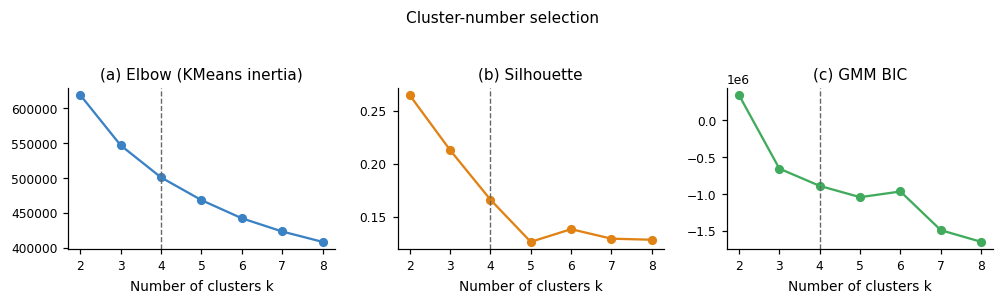

In [3]:
# === Cell 3 · How many phenotypes? (internal validity indices) ============
rows=[]
for k in range(2,9):
    km=KMeans(n_clusters=k,n_init=10,random_state=0).fit(Xz)
    rows.append(dict(k=k,inertia=round(km.inertia_),
       silhouette=round(silhouette_score(Xz,km.labels_,sample_size=6000,random_state=0),3),
       CH=round(calinski_harabasz_score(Xz,km.labels_)),DB=round(davies_bouldin_score(Xz,km.labels_),3),
       BIC=round(GaussianMixture(k,covariance_type="full",random_state=0,n_init=3).fit(Xz).bic(Xz))))
sel=pd.DataFrame(rows); sel.to_csv(os.path.join(OUT,"tableS_selection.csv"),index=False); display(sel)
K=4   # silhouette favours the trivial k=2 intensity split; k=4 = inertia elbow + interpretability + stability
fig,ax=plt.subplots(1,3,figsize=(9.2,2.7))
for a,(col,ttl,cl,sc,ylab) in zip(ax,[("inertia","(a) Within-cluster inertia (elbow)",PALETTE[0],1e5,"Inertia (\u00d710\u2075)"),
        ("silhouette","(b) Silhouette coefficient",PALETTE[1],1,"Silhouette"),
        ("BIC","(c) Gaussian-mixture BIC",PALETTE[2],1e6,"BIC (\u00d710\u2076)")]):
    a.plot(sel.k,sel[col]/sc,"o-",color=cl,ms=5); a.set_xlabel("Number of clusters k"); a.set_ylabel(ylab); a.set_title(ttl,fontsize=9)
    a.axvline(K,ls="--",lw=0.9,color="0.4")
fig.tight_layout(); save(fig,"fig1_selection"); plt.show()

Stability:  bootstrap ARI = 0.927 (sd 0.068) ;  KMeans-vs-Ward ARI = 0.466
Phenotypes: {0: 'Low-exposure', 1: 'Interpersonal', 2: 'Physical-env.', 3: 'High-intensity'}


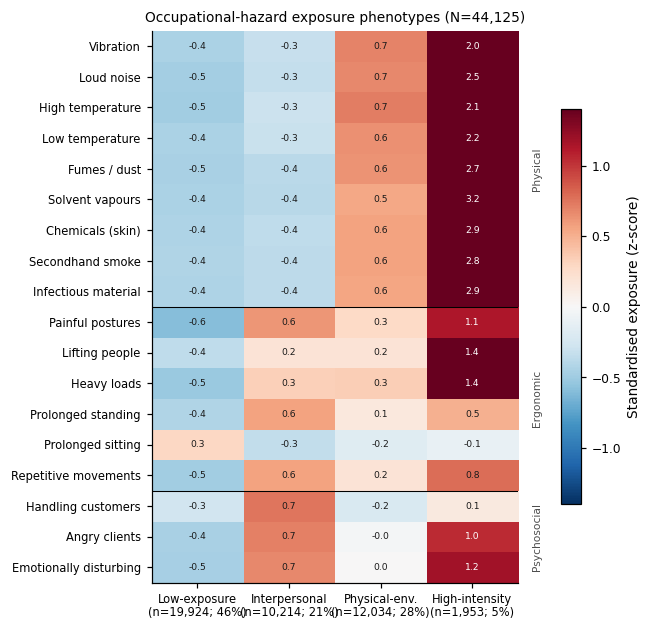

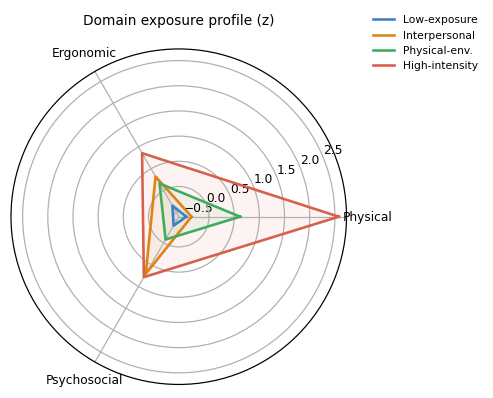

In [4]:
# === Cell 4 · Fit 4 phenotypes; stability; exposure profiles (heatmap + radar) ==
km=KMeans(n_clusters=K,n_init=30,random_state=0).fit(Xz)
boot=[adjusted_rand_score(km.labels_,
        KMeans(K,n_init=5,random_state=b).fit(Xz[np.random.RandomState(b).choice(len(Xz),len(Xz),True)]).predict(Xz))
      for b in range(25)]
si=np.random.RandomState(0).choice(len(Xz),8000,replace=False)
ari_ward=adjusted_rand_score(km.labels_[si],AgglomerativeClustering(n_clusters=K,linkage="ward").fit_predict(Xz[si]))
print(f"Stability:  bootstrap ARI = {np.mean(boot):.3f} (sd {np.std(boot):.3f}) ;  KMeans-vs-Ward ARI = {ari_ward:.3f}")

# name phenotypes from their domain profile (robust to label switching)
Zc=df.assign(**{c:Xz[:,j] for j,c in enumerate(HAZ)})
tmp=pd.DataFrame(Xz,columns=HAZ); tmp["c"]=km.labels_
dm=pd.DataFrame({"PHY":tmp.groupby("c")[PHY].mean().mean(1),"ERG":tmp.groupby("c")[ERG].mean().mean(1),
                 "PSY":tmp.groupby("c")[PSY].mean().mean(1)}); dm["ALL"]=tmp.groupby("c")[HAZ].mean().mean(1)
hi=dm.ALL.idxmax(); lo=dm.ALL.idxmin(); rest=[c for c in dm.index if c not in (hi,lo)]
inter=max(rest,key=lambda c:dm.PSY[c]-dm.PHY[c]); phys=[c for c in rest if c!=inter][0]
SHORT={lo:"Low-exposure",inter:"Interpersonal",phys:"Physical-env.",hi:"High-intensity"}
order=[lo,inter,phys,hi]; remap={o:i for i,o in enumerate(order)}; df["cl"]=[remap[l] for l in km.labels_]
names=[SHORT[order[i]] for i in range(K)]
profz=df.assign(**{c:Xz[:,j] for j,c in enumerate(HAZ)}).groupby("cl")[HAZ].mean()
sizes=df.cl.value_counts().sort_index()
wshare=df.groupby("cl").wt2.sum(); wshare=(wshare/wshare.sum()*100)
dom=pd.DataFrame({"Physical":df.assign(**{c:Xz[:,j] for j,c in enumerate(HAZ)}).groupby("cl")[PHY].mean().mean(1),
 "Ergonomic":df.assign(**{c:Xz[:,j] for j,c in enumerate(HAZ)}).groupby("cl")[ERG].mean().mean(1),
 "Psychosocial":df.assign(**{c:Xz[:,j] for j,c in enumerate(HAZ)}).groupby("cl")[PSY].mean().mean(1)})
profz.to_csv(os.path.join(OUT,"table1_profile_z.csv"))
print("Phenotypes:",{i:names[i] for i in range(K)})

fig,ax=plt.subplots(figsize=(6.6,5.8)); M=profz.T.values
im=ax.imshow(M,aspect="auto",cmap="RdBu_r",vmin=-1.4,vmax=1.4)
ax.set_xticks(range(K)); ax.set_xticklabels([f"{names[i]}\nn={sizes[i]:,} ({wshare[i]:.0f}%)" for i in range(K)],fontsize=7.6)
ax.set_yticks(range(len(HAZ))); ax.set_yticklabels([LBL[h] for h in HAZ],fontsize=7.5)
for i in range(len(HAZ)):
    for j in range(K): ax.text(j,i,f"{(0.0 if abs(M[i,j])<0.05 else M[i,j]):.1f}",ha="center",va="center",fontsize=6,color="white" if abs(M[i,j])>0.8 else "0.1")
for y in (8.5,14.5): ax.axhline(y,color="k",lw=0.7)
for yy,t in [(4,"Physical"),(11.5,"Ergonomic"),(16,"Psychosocial")]: ax.text(K-0.35,yy,t,rotation=90,va="center",fontsize=7,color="0.3")
cb=fig.colorbar(im,ax=ax,fraction=0.046,pad=0.10,extend="both"); cb.set_label("Standardised exposure (z-score)")
fig.tight_layout(); save(fig,"fig2_heatmap"); plt.show()

cats=list(dom.columns); ang=np.linspace(0,2*np.pi,len(cats),endpoint=False).tolist(); ang+=ang[:1]
fig=plt.figure(figsize=(4.4,4.0)); axr=plt.subplot(111,polar=True)
for i in range(K):
    v=dom.loc[i].tolist(); v+=v[:1]; axr.plot(ang,v,color=PALETTE[i],lw=1.7,label=names[i]); axr.fill(ang,v,color=PALETTE[i],alpha=0.07)
axr.set_xticks(ang[:-1]); axr.set_xticklabels(cats,fontsize=8); axr.set_title("Domain exposure profile (z)",fontsize=9,pad=16)
axr.legend(loc="upper right",bbox_to_anchor=(1.42,1.13),frameon=False,fontsize=7)
fig.tight_layout(); save(fig,"fig_radar"); plt.show()

In [ ]:
# === Cell 4b · Bootstrap stability across k (B=500) ==========================
# Manuscript SS2.4/SS3.1 + Supporting Table: ARI of each bootstrap re-clustering vs full-sample reference, k=2-8.
# NOTE: heavy (~30-90 min depending on cores). Skip by setting B_BOOT=0.
from joblib import Parallel, delayed
B_BOOT=500
def _boot_rep(k,ref,b):
    rs=np.random.RandomState(b); idx=rs.choice(len(Xz),len(Xz),True)
    return adjusted_rand_score(ref,KMeans(k,n_init=5,random_state=b).fit(Xz[idx]).predict(Xz))
if B_BOOT:
    rows=[]
    for k in range(2,9):
        ref=KMeans(k,n_init=30,random_state=0).fit(Xz).labels_
        vals=np.array(Parallel(n_jobs=max(1,(os.cpu_count() or 2)-1))(delayed(_boot_rep)(k,ref,b) for b in range(B_BOOT)))
        lo,hi=np.percentile(vals,[2.5,97.5])
        rows.append({"k":k,"B":B_BOOT,"ARI mean":round(vals.mean(),3),"ARI sd":round(vals.std(),3),
                     "2.5%":round(lo,3),"97.5%":round(hi,3)})
        print(f"k={k}: {vals.mean():.3f} (sd {vals.std():.3f}; 95% {lo:.3f}-{hi:.3f})",flush=True)
    boot_tab=pd.DataFrame(rows); boot_tab.to_csv(os.path.join(OUT,"tableS_bootstrap500.csv"),index=False); display(boot_tab)


In [ ]:
# === Cell 4c · Model-based cross-check: Gaussian mixtures (LPA analogue) =====
# Manuscript SS3.1: GMM under 4 covariance structures vs the k-means partition.
def _map4(labels):
    tg=pd.DataFrame(Xz,columns=HAZ); tg["c"]=labels
    dmg=pd.DataFrame({"PHY":tg.groupby("c")[PHY].mean().mean(1),"ERG":tg.groupby("c")[ERG].mean().mean(1),
                      "PSY":tg.groupby("c")[PSY].mean().mean(1)}); dmg["ALL"]=tg.groupby("c")[HAZ].mean().mean(1)
    hi_=dmg.ALL.idxmax(); lo_=dmg.ALL.idxmin(); rest=[c for c in dmg.index if c not in (hi_,lo_)]
    it_=max(rest,key=lambda c:dmg.PSY[c]-dmg.PHY[c]); ph_=[c for c in rest if c!=it_][0]
    order_=[lo_,it_,ph_,hi_]; rmp={o:i for i,o in enumerate(order_)}
    return np.array([rmp[l] for l in labels]), dmg.loc[order_].reset_index(drop=True)
rows=[]; gmm_prof={}
for cov in ["diag","full","tied","spherical"]:
    g=GaussianMixture(n_components=K,covariance_type=cov,n_init=5,random_state=0,max_iter=500).fit(Xz)
    lab=g.predict(Xz); post=g.predict_proba(Xz)
    ent=1-(-(post*np.log(np.clip(post,1e-12,None))).sum())/(len(Xz)*np.log(K))
    labm,domg=_map4(lab); gmm_prof[cov]=domg.round(2)
    rows.append({"covariance":cov,"BIC":round(g.bic(Xz)),"ARI vs k-means":round(adjusted_rand_score(df.cl.values,lab),3),
                 "agreement":round((labm==df.cl.values).mean(),3),"relative entropy":round(ent,3)})
gmm_tab=pd.DataFrame(rows); gmm_tab.to_csv(os.path.join(OUT,"tableS_gmm_crosscheck.csv"),index=False); display(gmm_tab)
print("GMM(diag) domain profiles (ordered Low/Inter/Phys/High by the same rule):"); display(gmm_prof["diag"])


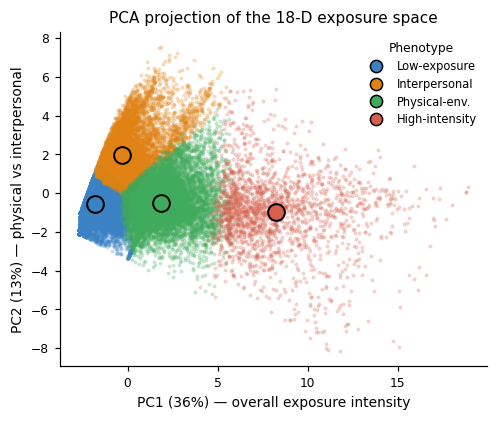

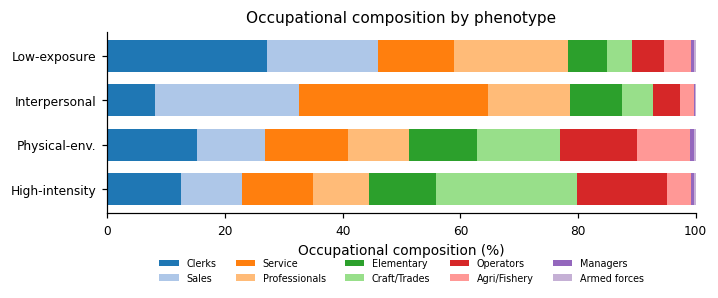

In [5]:
# === Cell 5 · PCA projection + occupational composition (face validity) ======
P=PCA(2,random_state=0).fit(Xz); XY=P.transform(Xz); ev=P.explained_variance_ratio_*100
fig,ax=plt.subplots(figsize=(4.6,3.9))
for i in range(K):
    m=df.cl.values==i; ax.scatter(XY[m,0],XY[m,1],s=3,alpha=0.20,color=PALETTE[i],rasterized=True)
for i in range(K):
    cx,cy=XY[df.cl.values==i].mean(0); ax.scatter(cx,cy,marker="o",s=120,facecolor=PALETTE[i],edgecolor="k",lw=1.3,zorder=5)
ax.legend(handles=[Line2D([0],[0],marker="o",ls="",mfc=PALETTE[i],mec="k",ms=8,label=names[i]) for i in range(K)],
          frameon=False,fontsize=7.5,loc="upper right",title="Profile",title_fontsize=8)
ax.set_xlabel(f"PC1 ({ev[0]:.1f}%) — overall exposure intensity"); ax.set_ylabel(f"PC2 ({ev[1]:.1f}%) — physical vs interpersonal")
fig.tight_layout(); save(fig,"fig3_pca"); plt.show()

OCC={1:"Managers",2:"Professionals",3:"Clerks",4:"Service",5:"Sales",6:"Agri/Fishery",7:"Craft/Trades",8:"Operators",9:"Elementary",10:"Armed forces"}
df["occL"]=df["occ"].map(OCC)
occx=pd.crosstab(df["cl"],df["occL"],normalize="index")*100; occx.to_csv(os.path.join(OUT,"table_occ_share.csv"))
fig,ax=plt.subplots(figsize=(6.6,2.9)); left=np.zeros(K); cm=plt.cm.tab20
for j,oc in enumerate(df["occL"].value_counts().index):
    if oc not in occx.columns: continue
    ax.barh(range(K),occx[oc].values,left=left,color=cm(j%20),label=oc,height=0.72); left+=occx[oc].values
ax.set_yticks(range(K)); ax.set_yticklabels(names); ax.set_xlim(0,100); ax.set_xlabel("Occupational composition (%)")
ax.invert_yaxis(); ax.legend(ncol=5,fontsize=6.3,frameon=False,bbox_to_anchor=(0.5,-0.20),loc="upper center")
fig.tight_layout(); save(fig,"fig5_occupation"); plt.show()

## Reviewer defence — why k=4, not the silhouette-optimal k=2?
The silhouette peaks at k=2 only because all 18 hazards are positively correlated, so the single strongest cut is by **overall intensity**. The cell below shows k=2 collapses to that intensity cut (parallel domain profiles; separation almost entirely along PC1), whereas k=4 additionally recovers the **physical-vs-interpersonal composition** axis (PC2) that distinguishes the Interpersonal and Physical-environmental phenotypes. Saved as `figS1_k2_vs_k4`.

In [ ]:
# === Cell 5b · Reviewer defence: k=2 (silhouette-optimal) vs k=4 =============
# Reuses in-memory df, Xz, HAZ, names, PALETTE, K, save(). Guarded; never breaks the run.
try:
    k2=KMeans(n_clusters=2,n_init=20,random_state=0).fit_predict(Xz)
    _int=Xz.mean(1)
    if _int[k2==0].mean()>_int[k2==1].mean(): k2=1-k2
    k2names=["Lower-intensity","Higher-intensity"]; k2col=["#c6dbef","#08519c"]
    _P=PCA(2,random_state=0).fit(Xz); _XY=_P.transform(Xz); _ev=_P.explained_variance_ratio_*100
    _comp=Xz[:,:9].mean(1)-Xz[:,15:18].mean(1)               # physical - psychosocial
    if np.corrcoef(_XY[:,1],_comp)[0,1]<0: _XY[:,1]=-_XY[:,1] # +PC2 = more physical-than-interpersonal
    _dl=["Physical","Ergonomic","Psychosocial"]
    def _dp(lab,g): return np.array([Xz[lab==g,:9].mean(),Xz[lab==g,9:15].mean(),Xz[lab==g,15:18].mean()])
    fig,ax=plt.subplots(2,2,figsize=(8.6,7.0))
    for g in (0,1):
        m=k2==g; ax[0,0].scatter(_XY[m,0],_XY[m,1],s=3,alpha=0.16,color=k2col[g],rasterized=True)
    ax[0,0].legend(handles=[Line2D([0],[0],marker="o",ls="",mfc=k2col[g],mec="k",ms=7,label=k2names[g]) for g in (0,1)],
                   frameon=False,fontsize=7,loc="upper right",title="k = 2 cluster",title_fontsize=7.5)
    ax[0,0].set_title("(a) k = 2 (silhouette-optimal): a single intensity cut")
    ax[0,0].set_xlabel(f"PC1 ({_ev[0]:.1f}%) - overall intensity"); ax[0,0].set_ylabel(f"PC2 ({_ev[1]:.1f}%) - physical vs interpersonal")
    for i in range(K):
        m=df.cl.values==i; ax[0,1].scatter(_XY[m,0],_XY[m,1],s=3,alpha=0.16,color=PALETTE[i],rasterized=True)
    ax[0,1].legend(handles=[Line2D([0],[0],marker="o",ls="",mfc=PALETTE[i],mec="k",ms=7,label=names[i]) for i in range(K)],
                   frameon=False,fontsize=6.8,loc="upper right",title="k = 4 profile",title_fontsize=7.5)
    ax[0,1].set_title("(b) k = 4: adds a composition split along PC2")
    ax[0,1].set_xlabel(f"PC1 ({_ev[0]:.1f}%) - overall intensity"); ax[0,1].set_ylabel(f"PC2 ({_ev[1]:.1f}%) - physical vs interpersonal")
    xd=np.arange(3)
    for g in (0,1): ax[1,0].plot(xd,_dp(k2,g),"o-",color=k2col[g],lw=2.2,label=k2names[g])
    ax[1,0].axhline(0,color="0.7",lw=0.8,ls="--"); ax[1,0].set_xticks(xd); ax[1,0].set_xticklabels(_dl)
    ax[1,0].set_ylabel("Std. exposure (z)"); ax[1,0].set_ylim(-0.8,1.4)
    ax[1,0].set_title("(c) k = 2 domain profiles - parallel (differ by level only)"); ax[1,0].legend(frameon=False,fontsize=7.5)
    for i in range(K): ax[1,1].plot(xd,_dp(df.cl.values,i),"o-",color=PALETTE[i],lw=2.2,label=names[i])
    ax[1,1].axhline(0,color="0.7",lw=0.8,ls="--"); ax[1,1].set_xticks(xd); ax[1,1].set_xticklabels(_dl)
    ax[1,1].set_ylabel("Std. exposure (z)"); ax[1,1].set_ylim(-0.8,2.9)
    ax[1,1].set_title("(d) k = 4 domain profiles - crossing (composition recovered)"); ax[1,1].legend(frameon=False,fontsize=6.5,ncol=2)
    fig.tight_layout(); save(fig,"figS1_k2_vs_k4"); plt.show()
    _d1=abs(_XY[k2==1,0].mean()-_XY[k2==0,0].mean()); _d2=abs(_XY[k2==1,1].mean()-_XY[k2==0,1].mean())
    _ii=names.index("Interpersonal"); _pi=names.index("Physical-env.")
    _p1=abs(_XY[df.cl.values==_ii,0].mean()-_XY[df.cl.values==_pi,0].mean()); _p2=abs(_XY[df.cl.values==_ii,1].mean()-_XY[df.cl.values==_pi,1].mean())
    print("k=2 centroids: |dPC1|=%.2f (intensity) vs |dPC2|=%.2f (composition)"%(_d1,_d2))
    print("k=4 Interpersonal vs Physical-env: |dPC1|=%.2f vs |dPC2|=%.2f (composition-dominant)"%(_p1,_p2))
    display(pd.crosstab(pd.Series(df.cl.values).map(dict(enumerate(names))),
                        pd.Series(k2).map(dict(enumerate(k2names))),normalize="index").mul(100).round(1))
except Exception as e:
    print("k2-vs-k4 defence skipped:",e)

In [ ]:
# === Cell 6 · Extra reviewer-grade visualisations (ridgeline · parallel · alluvial) ===
# Reuses in-memory results (df, Xz, names, HAZ); each block guarded so it never breaks the run.
from scipy.stats import gaussian_kde
from matplotlib.path import Path as _Path; from matplotlib.patches import PathPatch as _PP
_LBL=[LBL[h] for h in HAZ]; _int=Xz.mean(1); _K=len(names)
# (a) Ridgeline — exposure-intensity distribution per phenotype
try:
    fig,ax=plt.subplots(figsize=(6.0,3.8)); xs=np.linspace(_int.min(),_int.max(),300)
    for i in range(_K):
        v=_int[df["cl"].values==i]; ys=gaussian_kde(v)(xs); ys=ys/ys.max()*0.9
        ax.fill_between(xs,i,i+ys,color=PALETTE[i],alpha=0.7,lw=1,edgecolor="white",zorder=_K-i)
        ax.text(xs[0],i+0.12,names[i],fontsize=8,fontweight="bold")
    ax.set_yticks([]); ax.set_xlabel("Overall exposure intensity (mean z of 18 hazards)")
    ax.set_title("Exposure-intensity distribution by phenotype (ridgeline)")
    fig.tight_layout(); save(fig,"figW1_ridgeline"); plt.show()
except Exception as e: print("ridgeline skipped:",e)
# (b) Parallel coordinates — 18-hazard signature of each phenotype
try:
    cc=pd.DataFrame(Xz,columns=HAZ); cc["cl"]=df["cl"].values; cm=cc.groupby("cl")[HAZ].mean()
    fig,ax=plt.subplots(figsize=(8.6,3.6)); xp=np.arange(len(HAZ))
    for _,r in cc.sample(min(1200,len(cc)),random_state=0).iterrows():
        ax.plot(xp,r[HAZ].values,color=PALETTE[int(r.cl)],alpha=0.03,lw=0.5)
    for i in range(_K): ax.plot(xp,cm.loc[i].values,color=PALETTE[i],lw=2.4,marker="o",ms=3,label=names[i],zorder=5)
    for x in (8.5,14.5): ax.axvline(x,color="0.8",lw=0.8,ls="--")
    ax.set_xticks(xp); ax.set_xticklabels(_LBL,rotation=55,ha="right",fontsize=6.5)
    ax.set_ylabel("Std. exposure (z)"); ax.set_ylim(-1.2,2.9)
    ax.set_title("Parallel-coordinate exposure signatures of the phenotypes")
    ax.legend(fontsize=7,frameon=False,ncol=_K,loc="upper center",bbox_to_anchor=(0.5,1.16))
    fig.tight_layout(); save(fig,"figW2_parallel"); plt.show()
except Exception as e: print("parallel skipped:",e)
# (c) Alluvial — occupation -> phenotype flow
try:
    ct=pd.crosstab(df["occL"],df["cl"]); ct=ct.loc[ct.sum(1).sort_values(ascending=False).index]
    Ntot=ct.values.sum(); gap=0.012
    def _st(tot,vals):
        ys=[]; y=1.0
        for v in vals: h=v/tot*(1-gap*(len(vals)-1)); ys.append((y-h,y)); y-=h+gap
        return ys
    Lp=_st(Ntot,ct.sum(1).values); Rp=_st(Ntot,ct.sum(0).values)
    fig,ax=plt.subplots(figsize=(7.2,5.2)); xL,xR,bw=0.12,0.88,0.045; mid=(xL+xR)/2
    lo_={o:Lp[i][1] for i,o in enumerate(ct.index)}; ro_={c:Rp[c][1] for c in range(_K)}
    for o in ct.index:
        for c in range(_K):
            v=ct.loc[o,c]
            if v<=0: continue
            hL=v/Ntot*(1-gap*(len(ct)-1)); hR=v/Ntot*(1-gap*(_K-1))
            l1=lo_[o]; l0=l1-hL; lo_[o]=l0; r1=ro_[c]; r0=r1-hR; ro_[c]=r0
            verts=[(xL+bw,l0),(mid,l0),(mid,r0),(xR-bw,r0),(xR-bw,r1),(mid,r1),(mid,l1),(xL+bw,l1),(xL+bw,l0)]
            codes=[_Path.MOVETO,_Path.CURVE4,_Path.CURVE4,_Path.CURVE4,_Path.LINETO,_Path.CURVE4,_Path.CURVE4,_Path.CURVE4,_Path.CLOSEPOLY]
            ax.add_patch(_PP(_Path(verts,codes),facecolor=PALETTE[c],edgecolor="none",alpha=0.45))
    for i,o in enumerate(ct.index):
        y0,y1=Lp[i]; ax.add_patch(plt.Rectangle((xL,y0),bw,y1-y0,color="0.3")); ax.text(xL-0.01,(y0+y1)/2,o,ha="right",va="center",fontsize=7)
    for c in range(_K):
        y0,y1=Rp[c]; ax.add_patch(plt.Rectangle((xR-bw,y0),bw,y1-y0,color=PALETTE[c])); ax.text(xR+0.01,(y0+y1)/2,names[c],ha="left",va="center",fontsize=7.5,fontweight="bold")
    ax.set_xlim(0,1); ax.set_ylim(0,1.02); ax.axis("off"); ax.set_title("From occupation to exposure phenotype (alluvial)")
    fig.tight_layout(); save(fig,"figW3_alluvial"); plt.show()
except Exception as e: print("alluvial skipped:",e)

,phenotype,n,pres %,pres_lo,pres_hi,pres wtd%,absent %,absent_lo,absent_hi,absent wtd%,poorwlb %,poorwlb_lo,poorwlb_hi,poorwlb wtd%,engage
0,Low-exposure,19924,4.00,3.71,4.31,3.72,3.65,3.39,3.92,3.47,18.51,17.98,19.06,17.43,3.557
1,Interpersonal,10214,8.13,7.57,8.74,6.98,4.19,3.82,4.60,4.13,30.95,30.06,31.86,27.87,3.521
2,Physical-env.,12034,9.78,9.21,10.38,9.10,6.06,5.64,6.51,6.49,26.01,25.23,26.80,24.74,3.470
3,High-intensity,1953,7.19,6.03,8.54,7.71,3.37,2.65,4.28,3.58,31.66,29.63,33.76,30.20,3.358


chi-square p: {'pres': '6.7e-80', 'absent': '3.0e-23', 'poorwlb': '1.7e-148'} | engagement ANOVA p = 4.0e-42


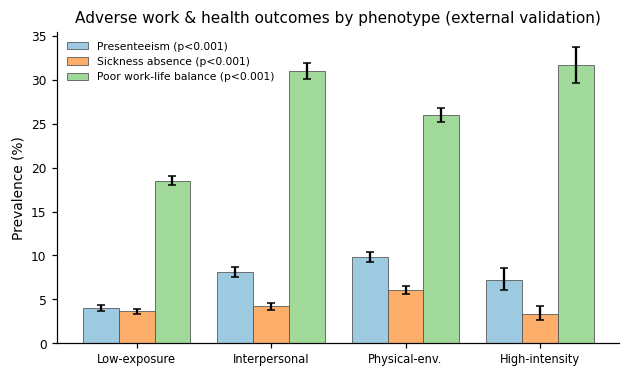

In [6]:
# === Cell 6 · External validation on UNTOUCHED outcomes =====================
def wilson(p,n,z=1.96):
    if n==0 or np.isnan(p): return (np.nan,np.nan)
    d=1+z*z/n; c=p+z*z/(2*n); h=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n)); return ((c-h)/d,(c+h)/d)
df["pres"]=np.where(df.heal_wsick1==1,1,np.where(df.heal_wsick1==2,0,np.nan))          # presenteeism
ab=df.heal_abs1.where(df.heal_abs1<=365); df["absent"]=np.where(ab.notna(),(ab>0).astype(float),np.nan)  # any sickness absence
wb=df.wbalance.where(df.wbalance.between(1,4)); df["poorwlb"]=np.where(wb.notna(),wb.isin([3,4]).astype(float),np.nan)
for c in ["weng1","weng2","weng3"]: df[c]=df[c].where(df[c].between(1,5))
df["engage"]=(6-df[["weng1","weng2","weng3"]]).mean(axis=1)                            # higher = more engaged
def wprev(sub,o):
    v=sub[[o,"wt2"]].dropna(); return np.average(v[o],weights=v.wt2)*100 if len(v) else np.nan
vr=[]
for i in range(K):
    sub=df[df.cl==i]; r={"phenotype":names[i],"n":len(sub)}
    for o in ["pres","absent","poorwlb"]:
        v=sub[o].dropna(); p=v.mean(); lo,hi=wilson(p,len(v))
        r[o+" %"]=round(p*100,2); r[o+"_lo"]=round(lo*100,2); r[o+"_hi"]=round(hi*100,2); r[o+" wtd%"]=round(wprev(sub,o),2)
    r["engage"]=round(sub.engage.mean(),3); vr.append(r)
val=pd.DataFrame(vr); val.to_csv(os.path.join(OUT,"table2_validation.csv"),index=False)
chip={o:stats.chi2_contingency(pd.crosstab(df.cl,df[o]))[1] for o in ["pres","absent","poorwlb"]}
engp=stats.f_oneway(*[df[df.cl==i].engage.dropna() for i in range(K)])[1]
display(val); print("chi-square p:",{k:f"{v:.1e}" for k,v in chip.items()},"| engagement ANOVA p =","%.1e"%engp)

nice={"pres":"Presenteeism","absent":"Sickness absence","poorwlb":"Poor work-life balance"}
fig,ax=plt.subplots(figsize=(5.8,3.5)); w=0.8/3
for j,o in enumerate(["pres","absent","poorwlb"]):
    xs=np.arange(K)+j*w; ys=val[o+" %"].values
    lo=ys-val[o+"_lo"].values; hi=val[o+"_hi"].values-ys
    ax.bar(xs,ys,w,yerr=[lo,hi],capsize=2.5,color=["#56B4E9","#E69F00","#CC79A7"][j],edgecolor="0.3",lw=0.5,
           label=nice[o])
ax.set_xticks(np.arange(K)+w); ax.set_xticklabels(names,fontsize=7.5); ax.set_ylabel("Prevalence (%)")
ax.legend(frameon=False,fontsize=7,loc="upper left"); fig.tight_layout(); save(fig,"fig4_validation"); plt.show()

In [ ]:
# === Cell 6b · Effect sizes · design-adjusted tests · covariate-adjusted models ===
# Manuscript SS2.5/SS3.4 + Table III. PSU ids are not released in the public-use file, so we use
# weight-normalised pseudo-ML (wt2 scaled to sample n) with HC1 robust SE.
try:
    import statsmodels.api as sm, statsmodels.formula.api as smf
    df["wn"]=df.wt2*len(df)/df.wt2.sum()
    df["occ_c"]=df.occ.where(df.occ.between(1,10)); df["emp_c"]=df.emp_type.where(df.emp_type>0)
    def _wald(fit):
        t=fit.wald_test_terms(skip_single=True).table.loc["C(cl)"]
        return float(np.squeeze(t["statistic"])), int(t["df_constraint"]), float(t["pvalue"])
    BINS={"pres":"Presenteeism","absent":"Sickness absence","poorwlb":"Poor work-life balance"}
    es=[]
    for o,nice in BINS.items():
        sub=df.dropna(subset=[o])
        tab=pd.crosstab(sub.cl,sub[o]); V=np.sqrt(stats.chi2_contingency(tab)[0]/(len(sub)*(min(tab.shape)-1)))
        wtab=sub.groupby(["cl",o]).wn.sum().unstack(); wtab=wtab*len(sub)/wtab.values.sum()
        Vw=np.sqrt(stats.chi2_contingency(wtab)[0]/(len(sub)*(min(wtab.shape)-1)))
        ws,wdf,wp=_wald(smf.glm(f"{o} ~ C(cl)",data=sub,freq_weights=sub.wn,family=sm.families.Binomial()).fit(cov_type="HC1"))
        es.append({"outcome":nice,"n":len(sub),"Cramer V":round(V,3),"Cramer V (wtd)":round(Vw,3),
                   "Wald chi2":round(ws,1),"df":wdf,"p":f"{wp:.1e}"})
    sube=df.dropna(subset=["engage"]); gr=[sube[sube.cl==i].engage for i in range(K)]
    ssb=sum(len(g_)*(g_.mean()-sube.engage.mean())**2 for g_ in gr); eta2=ssb/((sube.engage-sube.engage.mean())**2).sum()
    ws,wdf,wp=_wald(smf.wls("engage ~ C(cl)",data=sube,weights=sube.wn).fit(cov_type="HC1"))
    es.append({"outcome":"Work engagement","n":len(sube),"Cramer V":f"eta2={eta2:.4f}","Cramer V (wtd)":"",
               "Wald chi2":round(ws,1),"df":wdf,"p":f"{wp:.1e}"})
    es=pd.DataFrame(es); es.to_csv(os.path.join(OUT,"table_effect_sizes.csv"),index=False); display(es)
    adj=[]
    for o,nice in BINS.items():
        sub=df.dropna(subset=[o,"occ_c","emp_c","age","gender"]).copy()
        m=smf.glm(f"{o} ~ C(cl) + age + C(gender) + C(occ_c) + C(emp_c)",data=sub,
                  freq_weights=sub.wn,family=sm.families.Binomial()).fit(cov_type="HC1")
        ws,wdf,wp=_wald(m)
        base=sub.copy(); base["cl"]=0; p0=(m.predict(base)*sub.wn).sum()/sub.wn.sum()
        for i in (1,2,3):
            co=m.params[f"C(cl)[T.{i}]"]; se=m.bse[f"C(cl)[T.{i}]"]
            s2=sub.copy(); s2["cl"]=i; pi=(m.predict(s2)*sub.wn).sum()/sub.wn.sum()
            adj.append({"outcome":nice,"profile":names[i],
                        "aOR (95% CI)":f"{np.exp(co):.2f} ({np.exp(co-1.96*se):.2f}-{np.exp(co+1.96*se):.2f})",
                        "adj RD (pp)":round((pi-p0)*100,1),"joint Wald p":f"{wp:.1e}"})
    sube=df.dropna(subset=["engage","occ_c","emp_c","age","gender"]).copy()
    mE=smf.wls("engage ~ C(cl) + age + C(gender) + C(occ_c) + C(emp_c)",data=sube,weights=sube.wn).fit(cov_type="HC1")
    ws,wdf,wp=_wald(mE)
    for i in (1,2,3):
        co=mE.params[f"C(cl)[T.{i}]"]; se=mE.bse[f"C(cl)[T.{i}]"]
        adj.append({"outcome":"Work engagement","profile":names[i],
                    "aOR (95% CI)":f"b={co:.3f} ({co-1.96*se:.3f} to {co+1.96*se:.3f})",
                    "adj RD (pp)":"","joint Wald p":f"{wp:.1e}"})
    adj=pd.DataFrame(adj); adj.to_csv(os.path.join(OUT,"table3_adjusted.csv"),index=False); display(adj)
except Exception as e:
    print("Cell 6b skipped:",e)


In [7]:
# === Cell 7 · Phenotype summary table + saved-output manifest ===============
t1=pd.DataFrame({"Phenotype":names,"n":sizes.values,"Weighted %":wshare.round(1).values,
    "Physical (z)":dom["Physical"].round(2).values,"Ergonomic (z)":dom["Ergonomic"].round(2).values,
    "Psychosocial (z)":dom["Psychosocial"].round(2).values,"Mean age":df.groupby("cl").age.mean().round(1).values,
    "Female %":(df.groupby("cl").gender.apply(lambda s:(s==2).mean())*100).round(1).values,
    "Top occupation":[occx.loc[i].idxmax() for i in range(K)]})
t1.to_csv(os.path.join(OUT,"table1_summary.csv"),index=False); display(t1)
with open(os.path.join(OUT,"_summary.txt"),"w") as f:
    f.write(f"N={n2}; K={K}; bootstrapARI={np.mean(boot):.3f}; WardARI={ari_ward:.3f}; PC1={ev[0]:.1f}%; PC2={ev[1]:.1f}%\n\n")
    f.write(t1.to_string(index=False)+"\n\n"+val.to_string(index=False))
print("\nSaved to:",OUT); print("Files:",sorted(os.listdir(OUT)))

,Phenotype,n,Weighted %,Physical (z),Ergonomic (z),Psychosocial (z),Mean age,Female %,Top occupation
0,Low-exposure,19924,46.0,-0.45,-0.35,-0.39,48.4,55.1,Clerks
1,Interpersonal,10214,20.5,-0.35,0.32,0.71,49.1,63.8,Service
2,Physical-env.,12034,28.2,0.62,0.16,-0.08,50.6,41.4,Clerks
3,High-intensity,1953,5.2,2.58,0.86,0.79,50.7,31.5,Craft/Trades



Saved to: <PROJECT_ROOT> 드라이브/완석_구글자료/연구자료/20260313_kosha/4. 제주학술대회/컴퓨터정보_논문1/output/run_20260607_190631
Files: ['_summary.txt', 'fig1_selection.pdf', 'fig1_selection.png', 'fig2_heatmap.pdf', 'fig2_heatmap.png', 'fig3_pca.pdf', 'fig3_pca.png', 'fig4_validation.pdf', 'fig4_validation.png', 'fig5_occupation.pdf', 'fig5_occupation.png', 'fig_radar.pdf', 'fig_radar.png', 'table1_profile_z.csv', 'table1_summary.csv', 'table2_validation.csv', 'tableS_selection.csv', 'table_occ_share.csv']
